# Propagation in an elevated duct (JAX)

This notebook demonstrates radio wave propagation in an elevated atmospheric duct using the JAX-based solver.
For the legacy NumPy/Cython version, see [elevated_duct.ipynb](elevated_duct.ipynb).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), ".." if "uwa" not in os.getcwd() else "../..", "..", "..", "..")))
# Handle running from docs/source/notebooks or project root
for p in [".", "..", "../..", "../../..", "../../../.."]:
    full = os.path.abspath(p)
    if os.path.exists(os.path.join(full, "pywaveprop")):
        sys.path.insert(0, full)
        break


In [2]:
import jax
jax.config.update('jax_enable_x64', True)

import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

from pywaveprop.experimental.rwp_jax import (
    RWPGaussSourceModel,
    RWPComputationalParams,
    TroposphereModel,
    PiecewiseLinearNProfileModel,
    rwp_forward_task,
)

## Preparing environment

Elevated duct defined by a piecewise-linear M-profile.

In [3]:
max_range_m = 150e3

# M-profile values in M-units (same as legacy notebook).
# Use M0=0 and slope=0 since the profile already contains the full M.
z_prof = jnp.array([0.0, 100.0, 150.0, 300.0])
M_prof = jnp.array([0.0, 32.0, 10.0, 45.0])

n_profile = PiecewiseLinearNProfileModel(z_grid_m=z_prof, N_vals=M_prof)
env = TroposphereModel(N_profile=n_profile, M0=0, slope=0)


An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


## Preparing transmitting antenna

In [4]:
src = RWPGaussSourceModel(
    freq_hz=3e9,   # wavelength = 0.1 m
    height_m=30,
    beam_width_deg=2,
    elevation_angle_deg=0,
)

## Computing the electromagnetic field

In [5]:
params = RWPComputationalParams(
    max_range_m=max_range_m,
    max_height_m=300,
    dx_m=100,
    dz_m=1,
)

field = rwp_forward_task(src, env, params)

k_min: 62.831853071795855, k_max: 62.83513645499788
rational_approx_order: (5, 6), beta: 62.80748951675123, dx: 25.0, dz: 0.03125


## Visualising results

### Horizontal field slice at 30 m

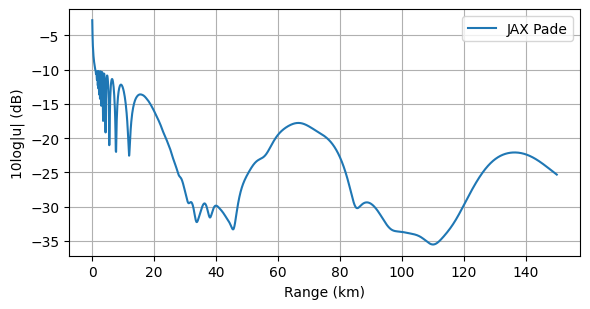

In [6]:
z_idx = np.argmin(np.abs(field.z_grid - 30))
data_hor = 10 * np.log10(np.abs(field.field[:, z_idx]) + 1e-16).real

plt.figure(figsize=(6, 3.2))
plt.plot(field.x_grid * 1e-3, data_hor, label='JAX Pade')
plt.xlabel('Range (km)')
plt.ylabel('10log|u| (dB)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### 2D field distribution

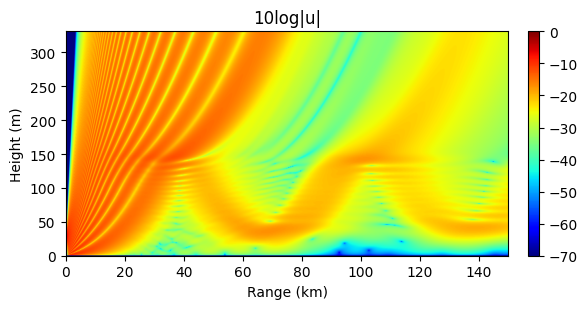

In [7]:
data_2d = 10 * np.log10(np.abs(field.field) + 1e-16).real
extent = [field.x_grid[0]*1e-3, field.x_grid[-1]*1e-3,
          field.z_grid[0], field.z_grid[-1]]

plt.figure(figsize=(6, 3.2))
plt.imshow(data_2d.T[::-1, :], extent=extent,
           norm=Normalize(-70, 0), aspect='auto', cmap='jet')
plt.colorbar(fraction=0.046, pad=0.04)
plt.title('10log|u|')
plt.xlabel('Range (km)')
plt.ylabel('Height (m)')
plt.tight_layout()
plt.show()